In [1]:
import os
from scipy.io import wavfile
import pandas as pd
import numpy as np

In [2]:
# Define the root folder containing all subfolders
root_folder = "task1/training"

# Prepare a list to store data
data = []

# Walk through all subfolders and files
for subdir, _, files in os.walk(root_folder):
    for file in files:
        if file.endswith('.wav'):
            filepath = os.path.join(subdir, file)
            sample_rate, audio = wavfile.read(filepath)
            # Store subfolder name for reference
            subfolder = os.path.basename(subdir)
            data.append({
                'filename': file,
                'patient_id': file.split('_')[0],
                'exercise': subfolder,
                'sample_rate': sample_rate,
                'audio': audio
            })

# Create a DataFrame
df = pd.DataFrame(data)

# Show the first few rows
df.head()

,filename,patient_id,exercise,sample_rate,audio
0,ID000_phonationA.wav,ID000,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ID001_phonationA.wav,ID001,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,ID002_phonationA.wav,ID002,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,ID003_phonationA.wav,ID003,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,ID005_phonationA.wav,ID005,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [3]:
# Load the Excel file with patient info
excel_path = "task1/sand_task_1.xlsx"
patient_info = pd.read_excel(excel_path, usecols=["ID", "Age", "Sex", "Class"], engine="openpyxl")

# Merge patient info into your main DataFrame
df = df.merge(patient_info, left_on="patient_id", right_on="ID", how="left")

# Drop the redundant 'ID' column if desired
df = df.drop(columns=["ID"])

# Show the updated DataFrame
df.head()

,filename,patient_id,exercise,sample_rate,audio,Age,Sex,Class
0,ID000_phonationA.wav,ID000,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",80,M,5
1,ID001_phonationA.wav,ID001,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",61,F,5
2,ID002_phonationA.wav,ID002,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",51,F,4
3,ID003_phonationA.wav,ID003,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",59,M,3
4,ID005_phonationA.wav,ID005,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",80,F,5


In [4]:
df.describe()

,sample_rate,Age,Class
count,2176.0,2176.000000,2176.000000
mean,8000.0,63.514706,3.926471
std,0.0,11.258949,1.085799
min,8000.0,23.000000,1.000000
25%,8000.0,56.750000,3.000000
50%,8000.0,64.500000,4.000000
75%,8000.0,72.000000,5.000000
max,8000.0,89.000000,5.000000


In [5]:
# Select randomly aproximatley 20% of patient to exclude and save their ids in a excluded_patient_ids.txt file
# N.B. The patients to exclude has to be ideally balanced between classes
# Get unique patients and their class
if False:  # Change to True to run again this block (Already executed once)
    patient_classes = df.groupby('patient_id')['Class'].first().reset_index()

    # Calculate number to exclude per class
    frac = 0.2
    to_exclude = (
        patient_classes.groupby('Class', group_keys=False)
        .apply(lambda x: x.sample(frac=frac, random_state=42))
    )

    excluded_patients = to_exclude['patient_id'].values

    # Save to file
    with open('excluded_patient_ids.txt', 'w') as f:
        for patient_id in excluded_patients:
            f.write(f"{patient_id}\n")

    # Exclude patients from the DataFrame
    df = df[~df['patient_id'].isin(excluded_patients)].reset_index(drop=True)
else:
    with open('excluded_patient_ids.txt', 'r') as f:
        excluded_patients = [line.strip() for line in f]

    # Exclude patients from the DataFrame
    df = df[~df['patient_id'].isin(excluded_patients)].reset_index(drop=True)

In [6]:
df.head()

,filename,patient_id,exercise,sample_rate,audio,Age,Sex,Class
0,ID001_phonationA.wav,ID001,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",61,F,5
1,ID005_phonationA.wav,ID005,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",80,F,5
2,ID006_phonationA.wav,ID006,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",73,M,5
3,ID007_phonationA.wav,ID007,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",72,M,3
4,ID009_phonationA.wav,ID009,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",51,F,3


Compute spectrograms

In [7]:
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from sklearn.utils import resample

class SpectrogramGenerator(Sequence):
    def __init__(self, df, patient_ids, batch_size=16,
                 n_mels=64, fmax=512, n_fft=1024, hop_length=512,
                 target_size=(128, 128), num_classes=3, shuffle=True,
                 augment=False, time_mask_param=20, freq_mask_param=10,
                 pitch_shift_range=2, time_stretch_range=0.1, noise_level=0.005,
                 balance_classes=True,
                 **kwargs):
        super().__init__(**kwargs)
        
        # Filter by patients
        self.df = df[df['patient_id'].isin(patient_ids)].reset_index(drop=True)
        self.batch_size = batch_size
        self.n_mels = n_mels
        self.fmax = fmax
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.target_size = target_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.augment = augment
        self.time_mask_param = time_mask_param
        self.freq_mask_param = freq_mask_param
        self.pitch_shift_range = pitch_shift_range
        self.time_stretch_range = time_stretch_range
        self.noise_level = noise_level
        self.balance_classes = balance_classes

        # Prepare balanced indices for training
        self._prepare_indices()
        self.on_epoch_end()

    def _prepare_indices(self):
        if self.balance_classes:
            # Oversample minority classes
            dfs = []
            max_count = self.df['class_idx'].value_counts().max()
            for c in self.df['class_idx'].unique():
                subset = self.df[self.df['class_idx'] == c]
                dfs.append(resample(subset, replace=True, n_samples=max_count, random_state=42))
            df_balanced = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
            self.df_balanced = df_balanced
            self.indices = np.arange(len(self.df_balanced))
        else:
            self.indices = np.arange(len(self.df))

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size)) + (len(self.df) % self.batch_size > 0)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        if len(batch_idx) == 0:
            raise IndexError("Empty batch requested")
        
        X, y = [], []

        df_use = self.df_balanced if self.balance_classes else self.df

        for i in batch_idx:
            row = df_use.iloc[i]

            # Convert list to np.array
            audio = np.array(row["audio"], dtype=np.float32)
            if len(audio) == 0:
                continue

            # Normalize audio to [-1, 1]
            audio = audio / (np.max(np.abs(audio)) + 1e-9)
            sr = row["sample_rate"]

            # Audio augmentation
            if self.augment:
                audio = self.apply_audio_augment(audio, sr)

            # Mel spectrogram
            S = librosa.feature.melspectrogram(
                y=audio, sr=sr,
                n_mels=self.n_mels,
                n_fft=self.n_fft,
                hop_length=self.hop_length,
                fmax=self.fmax
            )
            # Convert to dB using absolute reference to keep energy info
            S_db = librosa.power_to_db(S, ref=1.0)
            # Clip & scale to [0,1]
            S_db = np.clip(S_db, -80, 0)
            S_db = (S_db + 80) / 80

            # Resize to target size
            S_db = librosa.util.fix_length(S_db, size=self.target_size[1], axis=1)
            S_db = librosa.util.fix_length(S_db, size=self.target_size[0], axis=0)

            # SpecAugment
            if self.augment:
                S_db = self.apply_specaugment(S_db)

            X.append(S_db.astype(np.float32))
            y.append(row["class_idx"])

        X = np.array(X)[..., np.newaxis]  # add channel
        y = tf.keras.utils.to_categorical(y, num_classes=self.num_classes)
        return X, y

    def apply_audio_augment(self, audio, sr):
        # Pitch shift
        if len(audio) > 1:
            n_steps = np.random.uniform(-self.pitch_shift_range, self.pitch_shift_range)
            audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

        # Time stretch
        if len(audio) > 2:
            rate = np.random.uniform(1 - self.time_stretch_range, 1 + self.time_stretch_range)
            if len(audio) * rate > 10:
                audio = librosa.effects.time_stretch(audio, rate=rate)

        # Gaussian noise
        audio = audio + np.random.randn(len(audio)) * self.noise_level
        audio = np.clip(audio, -1.0, 1.0)
        return audio

    def apply_specaugment(self, mel):
        mask_val = mel.min()
        freq_max, time_max = mel.shape

        # Time mask
        t = np.random.randint(0, min(self.time_mask_param, time_max // 2) + 1)
        if t > 0:
            t0 = np.random.randint(0, max(1, time_max - t))
            mel[:, t0:t0+t] = mask_val

        # Frequency mask
        f = np.random.randint(0, min(self.freq_mask_param, freq_max // 2) + 1)
        if f > 0:
            f0 = np.random.randint(0, max(1, freq_max - f))
            mel[f0:f0+f, :] = mask_val

        return mel

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


In [8]:
import matplotlib.pyplot as plt

def visualize_spectrograms(generator, n_samples=4, augmented=False):
    """
    Show a few spectrograms from the generator.
    If augmented=True, use generator.augment = True temporarily.
    """
    # Store original augmentation setting
    prev_augment = generator.augment
    generator.augment = augmented

    # Get one batch
    X, y = generator[0]

    fig, axes = plt.subplots(1, n_samples, figsize=(15, 4))
    for i in range(n_samples):
        spec = X[i].squeeze()  # remove channel dimension
        axes[i].imshow(spec, aspect="auto", origin="lower", cmap="magma")
        axes[i].set_title(f"Class {np.argmax(y[i])}")
        axes[i].axis("off")

    plt.suptitle("Augmented" if augmented else "Original", fontsize=14)
    plt.show()

    # Reset augmentation setting
    generator.augment = prev_augment


In [9]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
import numpy as np

# -----------------------------
# Function to get valid folds
# -----------------------------
def make_valid_folds(df, n_splits=5, max_tries=10):
    """
    Create patient-level stratified folds ensuring:
    - All classes appear in both train and val
    - No patient leakage between train/val
    Tries up to `max_tries` different random seeds to find valid folds.
    """
    num_classes = df['class_idx'].nunique()
    folds = []
    tried = 0
    seed = 42

    while len(folds) < n_splits and tried < max_tries:
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        tried += 1
        print(f"🔄 Try {tried} with random_state={seed}")

        for fold, (train_idx, val_idx) in enumerate(
            sgkf.split(df, df['class_idx'], groups=df['patient_id'])
        ):
            train_df = df.iloc[train_idx]
            val_df   = df.iloc[val_idx]

            train_classes = set(train_df['class_idx'].unique())
            val_classes   = set(val_df['class_idx'].unique())

            missing_in_val = set(range(num_classes)) - val_classes
            missing_in_train = set(range(num_classes)) - train_classes

            if missing_in_val or missing_in_train:
                print(f"❌ Fold {fold} skipped – "
                      f"Val missing: {missing_in_val}, Train missing: {missing_in_train}")
                continue

            print(f"✅ Fold {fold} OK – all {num_classes} classes present")
            folds.append((train_idx, val_idx))

            if len(folds) == n_splits:
                break  # stop once we have enough

        seed += 1  # try next seed if not enough folds yet

    if len(folds) < n_splits:
        print(f"⚠️ Only {len(folds)} valid folds found after {tried} tries")
    else:
        print(f"🎉 Found {len(folds)} valid folds")

    return folds

# -----------------------------
# Encode labels (make them 0–4 instead of 1–5)
# -----------------------------
label_encoder = LabelEncoder()
df['class_idx'] = label_encoder.fit_transform(df['Class'])
num_classes = df['class_idx'].nunique()

# -----------------------------
# Generate folds
# -----------------------------
folds = make_valid_folds(df, n_splits=5, max_tries=10)

# Use first valid fold
train_idx, val_idx = folds[0]
train_df = df.iloc[train_idx]
val_df   = df.iloc[val_idx]

print("Train class distribution:", train_df['class_idx'].value_counts().to_dict())
print("Val class distribution:", val_df['class_idx'].value_counts().to_dict())

# -----------------------------
# Generators
# -----------------------------
train_gen = SpectrogramGenerator(train_df, train_df['patient_id'].unique(),
                                 batch_size=16, n_mels=128, target_size=(128,128),
                                 num_classes=num_classes, shuffle=True, augment=True)

val_gen = SpectrogramGenerator(val_df, val_df['patient_id'].unique(),
                               batch_size=16, n_mels=128, target_size=(128,128),
                               num_classes=num_classes, shuffle=False, augment=False)

# -----------------------------
# Class weights
# -----------------------------
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=train_gen.df['class_idx']
)
class_weights_dict = dict(zip(np.arange(num_classes), class_weights))
print("Class weights:", class_weights_dict)


🔄 Try 1 with random_state=42
❌ Fold 0 skipped – Val missing: {0}, Train missing: set()
✅ Fold 1 OK – all 5 classes present
❌ Fold 2 skipped – Val missing: {0}, Train missing: set()
✅ Fold 3 OK – all 5 classes present
✅ Fold 4 OK – all 5 classes present
🔄 Try 2 with random_state=43
✅ Fold 0 OK – all 5 classes present
❌ Fold 1 skipped – Val missing: {0, 1}, Train missing: set()
✅ Fold 2 OK – all 5 classes present
🎉 Found 5 valid folds
Train class distribution: {4: 560, 3: 360, 2: 288, 1: 152, 0: 32}
Val class distribution: {3: 128, 4: 128, 2: 80, 1: 16, 0: 8}
Class weights: {np.int64(0): np.float64(8.7), np.int64(1): np.float64(1.831578947368421), np.int64(2): np.float64(0.9666666666666667), np.int64(3): np.float64(0.7733333333333333), np.int64(4): np.float64(0.49714285714285716)}


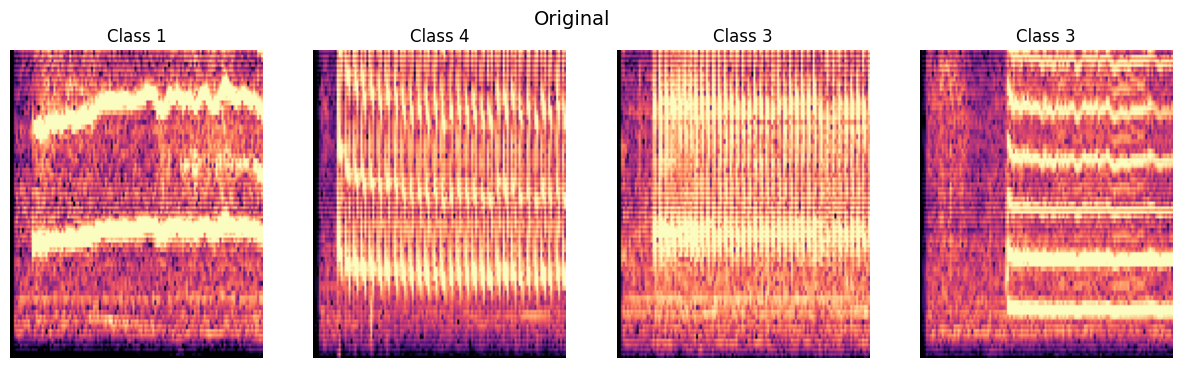

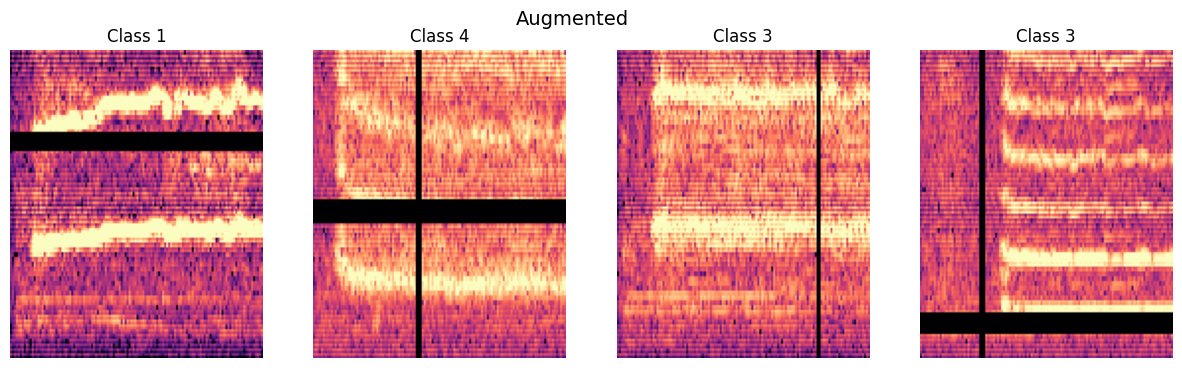

In [10]:
# Suppose you already created:
# train_gen = SpectrogramGenerator(..., augment=True)

# Show non-augmented spectrograms
visualize_spectrograms(train_gen, n_samples=4, augmented=False)

# Show augmented spectrograms
visualize_spectrograms(train_gen, n_samples=4, augmented=True)


In [11]:
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt

class F1ScoreCallback(Callback):
    def __init__(self, train_gen_eval, val_gen_eval):
        super().__init__()
        self.train_gen_eval = train_gen_eval
        self.val_gen_eval = val_gen_eval
        self.f1_scores = {"train": [], "val": []}

    def on_epoch_end(self, epoch, logs=None):
        # --- Train ---
        y_true_train = self.train_gen_eval.df["class_idx"].values
        y_pred_train = np.argmax(self.model.predict(self.train_gen_eval, verbose=0), axis=1)

        # Align lengths
        min_len = min(len(y_true_train), len(y_pred_train))
        y_true_train, y_pred_train = y_true_train[:min_len], y_pred_train[:min_len]

        f1_train = f1_score(y_true_train, y_pred_train, average="macro")

        # --- Val ---
        y_true_val = self.val_gen_eval.df["class_idx"].values
        y_pred_val = np.argmax(self.model.predict(self.val_gen_eval, verbose=0), axis=1)

        # Align lengths
        min_len = min(len(y_true_val), len(y_pred_val))
        y_true_val, y_pred_val = y_true_val[:min_len], y_pred_val[:min_len]

        f1_val = f1_score(y_true_val, y_pred_val, average="macro")

        # Save
        self.f1_scores["train"].append(f1_train)
        self.f1_scores["val"].append(f1_val)

        print(f" — val_f1: {f1_val:.3f} — train_f1: {f1_train:.3f}")

def plot_training_history_with_f1(history, f1_callback):
    hist = history.history

    plt.figure(figsize=(15, 5))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(hist['accuracy'], label='Train Accuracy')
    plt.plot(hist['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)

    # F1 Score
    plt.subplot(1, 3, 3)
    plt.plot(f1_callback.f1_scores["train"], label="Train F1 (macro)")
    plt.plot(f1_callback.f1_scores["val"], label="Val F1 (macro)")
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.title('F1 Score over Epochs')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [12]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras import layers, regularizers, models

def depthwise_separable_block(x, filters, stride=1, dropout=0.2, l2_reg=1e-4):
    # Depthwise conv
    x = layers.DepthwiseConv2D(
        3, strides=stride, padding="same",
        depthwise_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Pointwise conv
    x = layers.Conv2D(
        filters, 1, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Dropout for regularization
    x = layers.Dropout(dropout)(x)
    return x

def build_mobilenet_style(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = depthwise_separable_block(inputs, 32)
    x = depthwise_separable_block(x, 64, stride=2)
    x = depthwise_separable_block(x, 128, stride=2)
    x = depthwise_separable_block(x, 256, stride=2)

    # Global pooling instead of FC layers
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

input_shape = (128, 128, 1)  # freq bins = 128, time frames = 128
model = build_mobilenet_style(input_shape, num_classes)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -----------------------------
# Callbacks
# -----------------------------
f1_callback = F1ScoreCallback(train_gen, val_gen)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    f1_callback
]

# -----------------------------
# Training
# -----------------------------
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weights_dict
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 128, 128,  │         10 │ input_layer[0][0] │
│ (DepthwiseConv2D)   │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │          4 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │         64 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 64, 64,    │        320 │ dropout[0][0]     │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      2,112 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_2  │ (None, 32, 32,    │        640 │ dropout_1[0][0]   │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ depthwise_conv2d

 Total params: 114,899 (448.82 KB)

 Trainable params: 113,489 (443.32 KB)

 Non-trainable params: 1,410 (5.51 KB)

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1877 - loss: 7.3349 — val_f1: 0.009 — train_f1: 0.009
87/87 ━━━━━━━━━━━━━━━━━━━━ 406s 5s/step - accuracy: 0.1881 - loss: 7.3070 - val_accuracy: 0.1929 - val_loss: 1.6603 - learning_rate: 3.0000e-04
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2580 - loss: 2.5168 — val_f1: 0.017 — train_f1: 0.039
87/87 ━━━━━━━━━━━━━━━━━━━━ 354s 4s/step - accuracy: 0.2580 - loss: 2.5159 - val_accuracy: 0.1630 - val_loss: 1.6634 - learning_rate: 3.0000e-04
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2755 - loss: 2.3540 — val_f1: 0.017 — train_f1: 0.039
87/87 ━━━━━━━━━━━━━━━━━━━━ 333s 4s/step - accuracy: 0.2758 - loss: 2.3537 - val_accuracy: 0.1630 - val_loss: 1.6692 - learning_rate: 3.0000e-04
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2651 - loss: 2.3116 — val_f1: 0.104 — train_f1: 0.082
87/87 ━━━━━━━━━━━━━━━━━━━━ 335s 4s/step - accuracy: 0.2652 - loss: 2.3122 - val_accuracy: 0.2310 - v

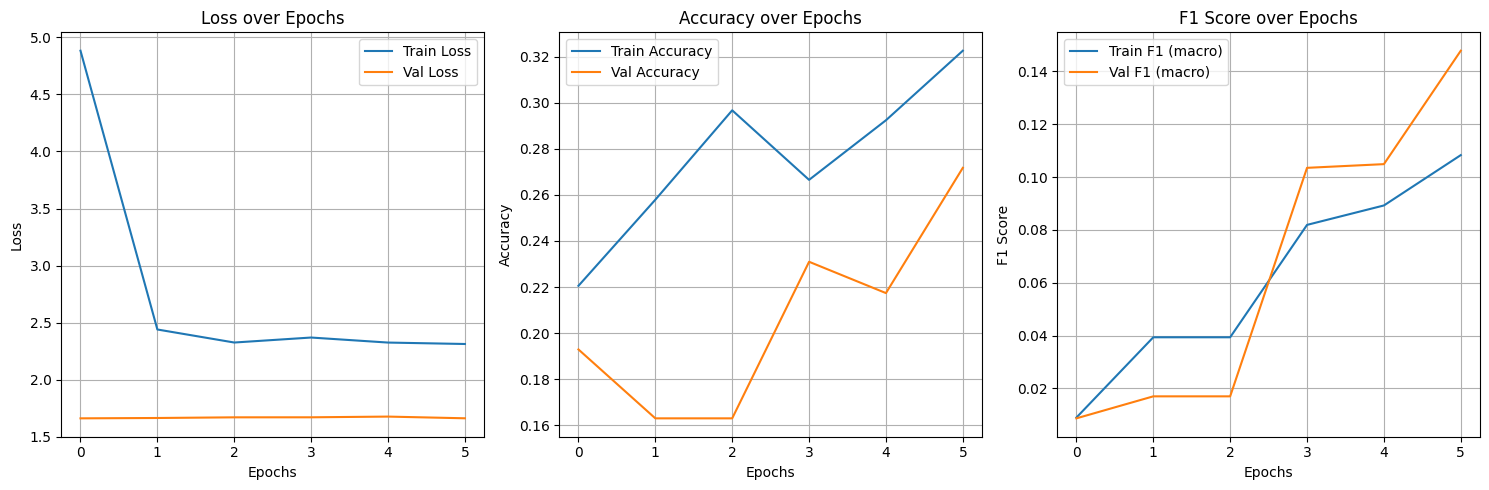

In [13]:
plot_training_history_with_f1(history, f1_callback)

In [14]:
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(model, generator, class_names, title="Confusion Matrix"):
    generator.shuffle = False  

    y_true, y_pred = [], []

    y_pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.df["class_idx"].values

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    assert len(y_true) == len(y_pred), f"Mismatch: {len(y_true)} vs {len(y_pred)}"

    cm = confusion_matrix(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{title} (Macro F1 = {f1:.3f})")
    plt.show()



def make_eval_generator(train_gen, shuffle=False):
    """
    Clone a SpectrogramGenerator with the same parameters but optionally no shuffle.
    Useful for evaluation (confusion matrix, F1, etc.).
    """
    return SpectrogramGenerator(
        df=train_gen.df,                     # same filtered dataframe
        patient_ids=train_gen.df['patient_id'].unique(),  # same patients
        batch_size=train_gen.batch_size,
        n_mels=train_gen.n_mels,
        n_fft=train_gen.n_fft,
        hop_length=train_gen.hop_length,
        target_size=train_gen.target_size,
        num_classes=train_gen.num_classes,
        shuffle=shuffle
    )


In [15]:
# -----------------------------
# Class names (in order of label encoder)
class_names = label_encoder.classes_

87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 143ms/step


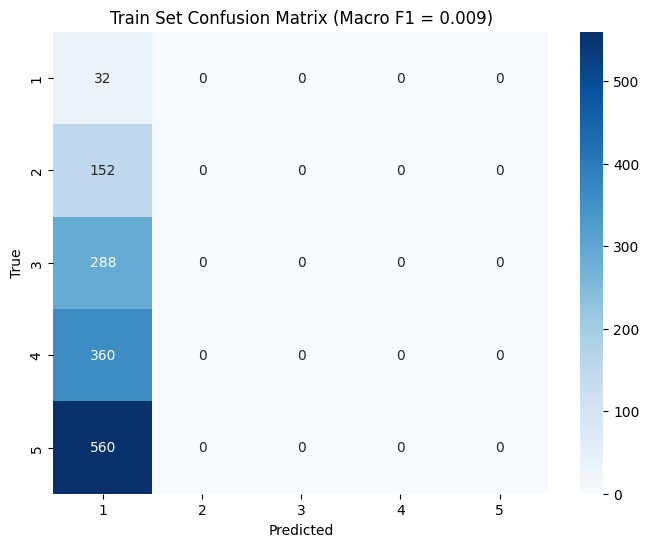

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step


AssertionError: Mismatch: 360 vs 368

In [16]:
# Create fixed-order generators for evaluation
train_gen_eval = make_eval_generator(train_gen, shuffle=False)
val_gen_eval   = make_eval_generator(val_gen, shuffle=False)

# Now safe to evaluate
plot_confusion_matrix(model, train_gen_eval, class_names, "Train Set Confusion Matrix")
plot_confusion_matrix(model, val_gen_eval, class_names, "Validation Set Confusion Matrix")
